# Experiment 5.2.2 — Frozen Local Multi-`tau_syn` Decoder

Analysis-only notebook. Temporal-profile selection uses mean validation native balanced accuracy only; test metrics are reported after selection. `theta=0.5` is fixed and is never used as a sweep variable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
root = repo_root / 'notebooks' / 'artifacts' / 'experiment_5_2_2_frozen_local_multitau_syn' / 'frozen_exp51_l2_multitau_syn_wholecount_v1'
runs = pd.read_csv(root / 'runs.csv')
ablations = pd.read_csv(root / 'ablation_runs.csv')
probes = pd.read_csv(root / 'probes.csv')
activity = pd.read_csv(root / 'activity.csv')
threshold_activity = pd.read_csv(root / 'threshold_activity.csv')
histories = pd.read_csv(root / 'histories.csv')
local_reference = pd.read_csv(root / 'local_reference.csv')
manifest = json.loads((root / 'manifest.json').read_text(encoding='utf-8'))
manifest

{'aggregation_policy': 'per-run tasks train then evaluate the selected checkpoint; finalizer concatenates only; notebook performs validation-only profile selection, paired effects, organization-gap diagnostics, bottleneck analysis, and plots',
 'checkpoint_selection': 'per-run max validation native BA; tie-break validation native CE',
 'expected_logical_ablation_rows': 420,
 'expected_training_runs': 60,
 'experiment_id': 'experiment_5_2_2_frozen_local_multitau_syn',
 'files': {'ablation_runs': 'ablation_runs.csv',
  'activity': 'activity.csv',
  'histories': 'histories.csv',
  'local_reference': 'local_reference.csv',
  'probes': 'probes.csv',
  'runs': 'runs.csv',
  'threshold_activity': 'threshold_activity.csv'},
 'interventions': ['normal',
  'resetall250',
  'reset234',
  'reset2345',
  'reset23456',
  'reset67',
  'reset567'],
 'local_reference_probes': ['local_whole_count',
  'local_fixed250_ordered',
  'local_relative10_ordered'],
 'output_synaptic_state': False,
 'probes': ['l

## Validation-only profile selection

In [2]:
profile_order = ['s2','s3','s4','s5','s6','s7','s234567','s4567','s567','s67']
native_summary = runs.groupby(['readout','profile']).agg(val_ba_mean=('native_val_balanced_accuracy','mean'), val_ba_sd=('native_val_balanced_accuracy','std'), test_ba_mean=('native_test_balanced_accuracy','mean'), test_ba_sd=('native_test_balanced_accuracy','std')).reset_index()
selection = native_summary.sort_values(['readout','val_ba_mean','profile'], ascending=[True,False,True]).groupby('readout', as_index=False).first()
display(native_summary.sort_values(['readout','profile']))
display(selection)

,readout,profile,val_ba_mean,val_ba_sd,test_ba_mean,test_ba_sd
0,hidden_count_linear,s2,0.453790,0.019102,0.423306,0.011716
1,hidden_count_linear,s234567,0.393813,0.045907,0.353472,0.041412
2,hidden_count_linear,s3,0.425245,0.014590,0.390380,0.036473
3,hidden_count_linear,s4,0.408500,0.016144,0.383280,0.034777
4,hidden_count_linear,s4567,0.349812,0.010798,0.330305,0.053434
5,hidden_count_linear,s5,0.353395,0.025138,0.320632,0.029622
6,hidden_count_linear,s567,0.347882,0.007962,0.346413,0.028377
7,hidden_count_linear,s6,0.340741,0.044767,0.327653,0.046115
8,hidden_count_linear,s67,0.351850,0.029274,0.323839,0.049092
9,hidden_count_linear,s7,0.327846,0.042115,0.324512,0.017456


,readout,profile,val_ba_mean,val_ba_sd,test_ba_mean,test_ba_sd
0,hidden_count_linear,s2,0.453790,0.019102,0.423306,0.011716
1,output_lif,s2,0.402684,0.026114,0.419787,0.021917


## Native profile sweep

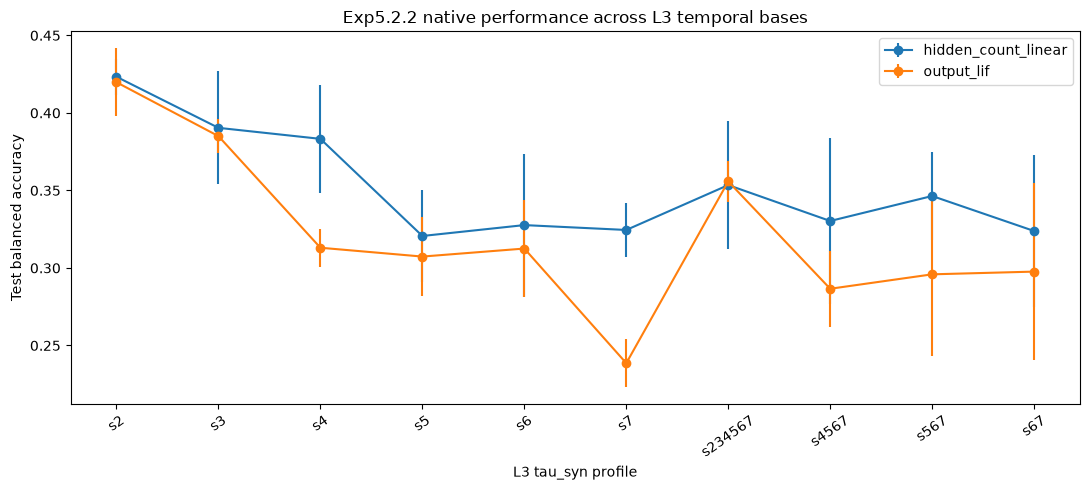

In [3]:
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(profile_order))
for readout, group in native_summary.groupby('readout'):
    ordered = group.set_index('profile').reindex(profile_order)
    ax.errorbar(x, ordered['test_ba_mean'], yerr=ordered['test_ba_sd'], marker='o', label=readout)
ax.set_xticks(x, profile_order, rotation=35)
ax.set_ylabel('Test balanced accuracy')
ax.set_xlabel('L3 tau_syn profile')
ax.set_title('Exp5.2.2 native performance across L3 temporal bases')
ax.legend()
fig.tight_layout()

## Frozen L2 to selected L3 representation accessibility

In [4]:
local_map = {'local_whole_count':'WholeCount','local_fixed250_ordered':'Fixed250','local_relative10_ordered':'Relative10'}
l3_map = {'l3_whole_count':'WholeCount','l3_fixed250_ordered':'Fixed250','l3_relative10_ordered':'Relative10'}
local_mean = local_reference.assign(stage='Frozen L2', metric=local_reference['probe_type'].map(local_map)).groupby(['stage','metric'], as_index=False)['test_ba'].mean()
selected_probe_rows = []
for _, picked in selection.iterrows():
    subset = probes[(probes.readout == picked.readout) & (probes.profile == picked.profile) & (probes.intervention == 'normal')].copy()
    subset['stage'] = f'L3 {picked.readout} / {picked.profile}'
    subset['metric'] = subset['probe_type'].map(l3_map)
    selected_probe_rows.append(subset[['stage','metric','test_ba']])
representation_flow = pd.concat([local_mean, *selected_probe_rows], ignore_index=True)
display(representation_flow.groupby(['stage','metric'], as_index=False).test_ba.mean())

,stage,metric,test_ba
0,Frozen L2,Fixed250,0.621977
1,Frozen L2,Relative10,0.704928
2,Frozen L2,WholeCount,0.557100
3,L3 hidden_count_linear / s2,Fixed250,0.550952
4,L3 hidden_count_linear / s2,Relative10,0.641625
5,L3 hidden_count_linear / s2,WholeCount,0.520612
6,L3 output_lif / s2,Fixed250,0.540265
7,L3 output_lif / s2,Relative10,0.626865
8,L3 output_lif / s2,WholeCount,0.510214


## Reset effects and organization_gap

In [5]:
reset_order = ['resetall250','reset234','reset2345','reset23456','reset67','reset567']
normal_native = ablations[ablations.intervention == 'normal'][['profile','readout','seed','native_test_balanced_accuracy']].rename(columns={'native_test_balanced_accuracy':'native_normal'})
reset_native = ablations[ablations.intervention != 'normal'].merge(normal_native, on=['profile','readout','seed'], how='left')
reset_native['delta_native_test_ba'] = reset_native['native_normal'] - reset_native['native_test_balanced_accuracy']
probe_wide = probes.pivot_table(index=['profile','readout','seed','intervention'], columns='probe_type', values='test_ba').reset_index()
normal_probe = probe_wide[probe_wide.intervention == 'normal'].drop(columns='intervention').rename(columns={'l3_whole_count':'wc_normal','l3_fixed250_ordered':'fixed_normal','l3_relative10_ordered':'rel_normal'})
reset_probe = probe_wide[probe_wide.intervention != 'normal'].merge(normal_probe, on=['profile','readout','seed'], how='left')
reset_probe['delta_whole_count'] = reset_probe['wc_normal'] - reset_probe['l3_whole_count']
reset_probe['delta_fixed250'] = reset_probe['fixed_normal'] - reset_probe['l3_fixed250_ordered']
reset_probe['delta_relative10'] = reset_probe['rel_normal'] - reset_probe['l3_relative10_ordered']
reset_probe['organization_gap'] = reset_probe['delta_whole_count'] - reset_probe['delta_fixed250']
display(reset_native.groupby(['readout','profile','intervention']).delta_native_test_ba.agg(['mean','std']))
display(reset_probe.groupby(['readout','profile','intervention'])[['delta_whole_count','delta_fixed250','delta_relative10','organization_gap']].mean())

mean       std
readout             profile intervention                    
hidden_count_linear s2      reset234     -0.014983  0.017785
                            reset2345    -0.014983  0.017785
                            reset23456   -0.014983  0.017785
                            reset567      0.000000  0.000000
                            reset67       0.000000  0.000000
...                                            ...       ...
output_lif          s7      reset2345     0.000000  0.000000
                            reset23456    0.000000  0.000000
                            reset567     -0.024715  0.046973
                            reset67      -0.024715  0.046973
                            resetall250  -0.024715  0.046973

[120 rows x 2 columns]

probe_type                                delta_whole_count  delta_fixed250  \
readout             profile intervention                                      
hidden_count_linear s2      reset234               0.005966        0.002785   
                            reset2345              0.005966        0.002785   
                            reset23456             0.005966        0.002785   
                            reset567               0.000000        0.000000   
                            reset67                0.000000        0.000000   
...                                                     ...             ...   
output_lif          s7      reset2345              0.000000        0.000000   
                            reset23456             0.000000        0.000000   
                            reset567              -0.117622       -0.143257   
                            reset67               -0.117622       -0.143257   
                            resetall250           -0.117622       -0.143257   

probe_type                                delta_relative10  organization_gap  
readout             profile intervention                                      
hidden_count_linear s2      reset234             -0.029997          0.003180  
                            reset2345            -0.029997          0.003180  
                            reset23456           -0.029997          0.003180  
                            reset567              0.000000          0.000000  
                            reset67               0.000000          0.000000  
...                                                    ...               ...  
output_lif          s7      reset2345             0.000000          0.000000  
                            reset23456            0.000000          0.000000  
                            reset567             -0.123536          0.025635  
                            reset67              -0.123536          0.025635  
                            resetall250          -0.123536          0.025635  

[120 rows x 4 columns]

## Output-LIF bottleneck

In [6]:
output_pick = selection[selection.readout == 'output_lif'].iloc[0]
output_profile = output_pick.profile
output_ab = ablations[(ablations.readout == 'output_lif') & (ablations.profile == output_profile)]
output_probe = probes[(probes.readout == 'output_lif') & (probes.profile == output_profile) & (probes.probe_type == 'l3_whole_count')][['seed','intervention','test_ba']].rename(columns={'test_ba':'fresh_count_probe_test_ba'})
bottleneck = output_ab.merge(output_probe, on=['seed','intervention'], how='left')
display(bottleneck.groupby('intervention')[['fresh_count_probe_test_ba','pre_lif_test_balanced_accuracy','native_test_balanced_accuracy']].mean())

,fresh_count_probe_test_ba,pre_lif_test_balanced_accuracy,native_test_balanced_accuracy
intervention,,,
normal,0.510214,0.399735,0.419787
reset234,0.489985,0.392857,0.404243
reset2345,0.489985,0.392857,0.404243
reset23456,0.489985,0.392857,0.404243
reset567,0.510214,0.399735,0.419787
reset67,0.510214,0.399735,0.419787
resetall250,0.489985,0.392857,0.404243


## Per-timescale activity and fixed-threshold operating point

,readout,profile,intervention,shift,event_rate_hz,nonzero_fraction,mean_abs_syn,rms_syn,mean_abs_mem
0,hidden_count_linear,s2,normal,2,16.428098,0.256689,0.875748,1.263089,1.458408
1,hidden_count_linear,s2,reset567,2,16.428098,0.256689,0.875748,1.263089,1.458408
2,hidden_count_linear,s2,reset67,2,16.428098,0.256689,0.875748,1.263089,1.458408
3,hidden_count_linear,s2,resetall250,2,14.788519,0.231071,0.732861,1.083054,1.117217
4,output_lif,s2,normal,2,17.250718,0.269542,0.997667,1.422787,1.686031
5,output_lif,s2,reset567,2,17.250718,0.269542,0.997667,1.422787,1.686031
6,output_lif,s2,reset67,2,17.250718,0.269542,0.997667,1.422787,1.686031
7,output_lif,s2,resetall250,2,15.784888,0.246639,0.833239,1.218514,1.286493


,readout,profile,intervention,shift,firing_rate_hz,spike_probability,mean_abs_input_current,mean_abs_pre_reset_membrane,pre_reset_above_threshold_probability
0,hidden_count_linear,s2,normal,2,16.428098,0.256689,0.875748,1.586752,0.256689
1,hidden_count_linear,s2,reset567,2,16.428098,0.256689,0.875748,1.586752,0.256689
2,hidden_count_linear,s2,reset67,2,16.428098,0.256689,0.875748,1.586752,0.256689
3,hidden_count_linear,s2,resetall250,2,14.788519,0.231071,0.732861,1.232752,0.231071
4,output_lif,s2,normal,2,17.250718,0.269542,0.997667,1.820802,0.269542
5,output_lif,s2,reset567,2,17.250718,0.269542,0.997667,1.820802,0.269542
6,output_lif,s2,reset67,2,17.250718,0.269542,0.997667,1.820802,0.269542
7,output_lif,s2,resetall250,2,15.784888,0.246639,0.833239,1.409812,0.246639


,readout,profile,intervention,shift,firing_rate_hz,spike_probability,mean_abs_input_current,mean_abs_pre_reset_membrane,pre_reset_above_threshold_probability


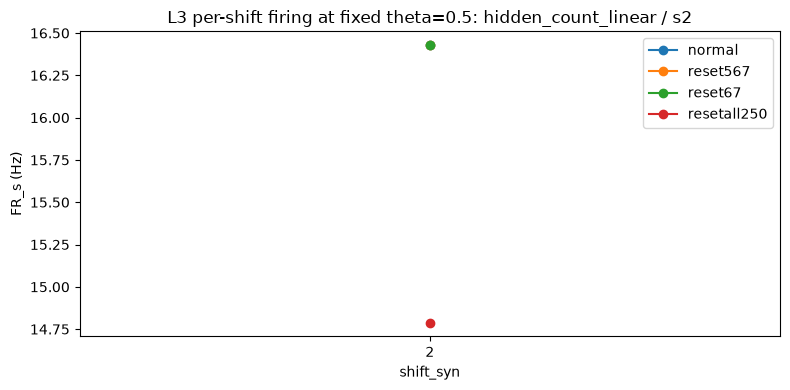

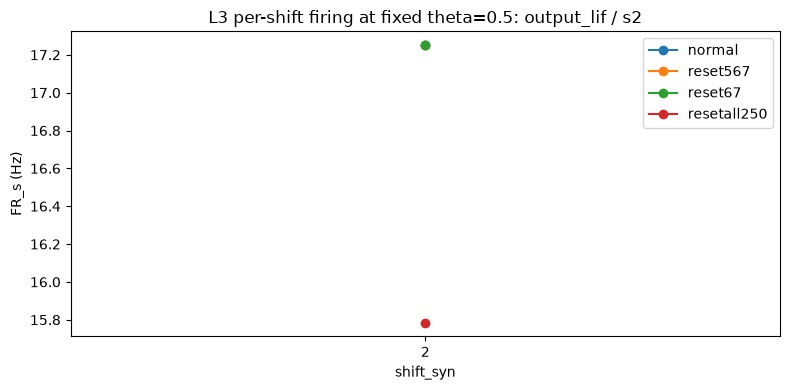

In [7]:
selected_profiles = set(selection.profile)
activity_selected = activity[activity.profile.isin(selected_profiles) & activity.intervention.isin(['normal','resetall250','reset67','reset567']) & (activity['split'] == 'test') & (activity['shift'].astype(str) != 'all')].copy()
activity_summary = activity_selected.groupby(['readout','profile','intervention','shift']).agg(event_rate_hz=('event_rate_hz','mean'), nonzero_fraction=('nonzero_fraction','mean'), mean_abs_syn=('mean_abs_syn','mean'), rms_syn=('rms_syn','mean'), mean_abs_mem=('mean_abs_mem','mean')).reset_index()
display(activity_summary)
threshold_selected = threshold_activity[threshold_activity.profile.isin(selected_profiles) & threshold_activity.intervention.isin(['normal','resetall250','reset67','reset567']) & (threshold_activity['split'] == 'test') & (threshold_activity['shift'].astype(str) != 'all')].copy()
threshold_summary = threshold_selected.groupby(['readout','profile','intervention','shift']).agg(firing_rate_hz=('firing_rate_hz','mean'), spike_probability=('spike_probability','mean'), mean_abs_input_current=('mean_abs_input_current','mean'), mean_abs_pre_reset_membrane=('mean_abs_pre_reset_membrane','mean'), pre_reset_above_threshold_probability=('pre_reset_above_threshold_probability','mean')).reset_index()
display(threshold_summary)
long_operating_point = threshold_summary[threshold_summary['shift'].astype(str).isin(['6','7'])].copy()
display(long_operating_point)
for (readout, profile), group in threshold_summary.groupby(['readout','profile']):
    fig, ax = plt.subplots(figsize=(8,4))
    for intervention, part in group.groupby('intervention'):
        part = part.sort_values('shift', key=lambda s: s.astype(int))
        ax.plot(part['shift'].astype(str), part['firing_rate_hz'], marker='o', label=intervention)
    ax.set_title(f'L3 per-shift firing at fixed theta=0.5: {readout} / {profile}')
    ax.set_xlabel('shift_syn')
    ax.set_ylabel('FR_s (Hz)')
    ax.legend()
    fig.tight_layout()

The fixed-threshold table reports `FR_s`, `P(S_t=1)`, `E|I_t|`, `E|U_t^-|`, and `P(U_t^- > theta)` per `tau_syn` group. Shifts 6 and 7 are the primary long-timescale operating-point diagnostics.

## Paired effects and selected learning curves

,mean,std,min,max
profile,,,,
s2,0.003519,0.025400,-0.015368,0.032395
s234567,-0.002323,0.042323,-0.039476,0.043748
s3,0.005346,0.029435,-0.014071,0.039214
s4,0.070231,0.033431,0.040039,0.106158
s4567,0.043716,0.054357,-0.006484,0.101445
s5,0.013279,0.042556,-0.020844,0.060962
s567,0.050515,0.037194,0.009149,0.081199
s6,0.015132,0.016288,-0.002838,0.028925
s67,0.026189,0.079008,-0.022215,0.117361


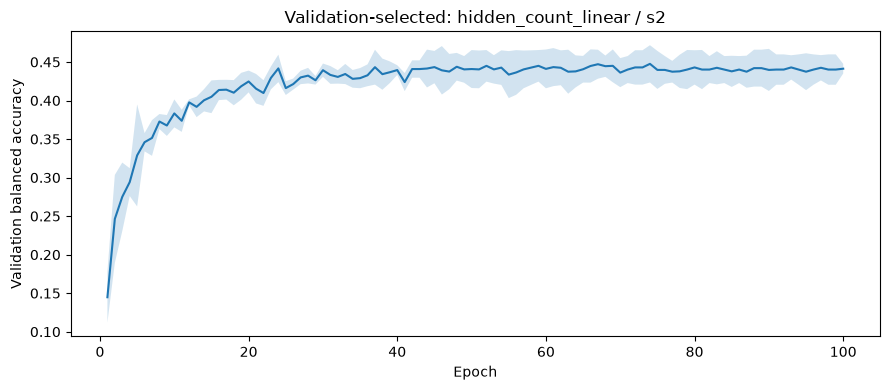

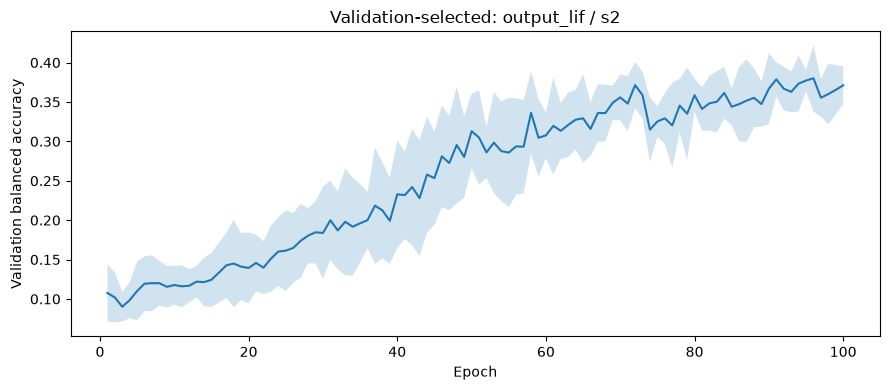

In [8]:
paired_readout = runs.pivot_table(index=['profile','seed'], columns='readout', values='native_test_balanced_accuracy').dropna().reset_index()
paired_readout['hidden_count_minus_output_lif'] = paired_readout['hidden_count_linear'] - paired_readout['output_lif']
display(paired_readout.groupby('profile').hidden_count_minus_output_lif.agg(['mean','std','min','max']))
for _, picked in selection.iterrows():
    curve = histories[(histories.readout == picked.readout) & (histories.profile == picked.profile)]
    summary = curve.groupby('epoch').val_balanced_accuracy.agg(['mean','std']).reset_index()
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(summary['epoch'], summary['mean'])
    ax.fill_between(summary['epoch'], summary['mean'] - summary['std'].fillna(0), summary['mean'] + summary['std'].fillna(0), alpha=0.2)
    ax.set_title(f'Validation-selected: {picked.readout} / {picked.profile}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation balanced accuracy')
    fig.tight_layout()